# Дослідження 01 - Що бачить комп'ютер

1. **Основне завдання:** Завантажте будь-яке кольорове фото (власне або з URL) і виконайте:
    1. відобразіть три канали BGR окремо;
    2. побудуйте гістограму по каналах і гістограму каналу V у HSV – порівняйте що інформативніше;
    3. зробіть center crop і resize до 224×224, порахуйте розмір у MB для uint8 і float32.
    _Підсумуйте: що вам розповіла гістограма про це фото?_
2. **Додаткове завдання:**
    1. вимкніть один канал `(img[:, :, 2] = 0)` і порівняйте результат з оригіналом;
    2. спробуйте alpha=0.5 (знижуємо контраст) і alpha=2.0 (підвищуємо) в `convertScaleAbs` – що відбувається з деталями;
    3. додайте шум sigma=10, 25 і 50 – при якому значенні деталі ще розпізнаються;
    4. порахуйте пам'ять для 4K кадру (3840×2160×3) у `uint8` і `float32`.


## 1.1. ОСНОВНЕ ЗАВДАННЯ
Згенеруємо кольорове зображення - згенеруємо його за допомогою викликів функцій бібліотекі OpenCV, що створюють геометричні фігури - `circle`, `ellipse`,`rectangle`. Створення зображення робимо в якості практики генерації зображень в OpenCV.

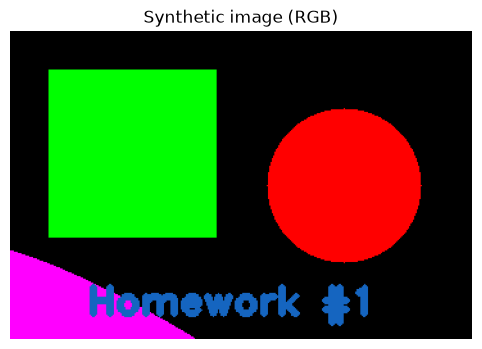

shape: (240, 360, 3) dtype: uint8
min/max: 0 255


In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ф-ція рендера зображення. img - зображення, title - назва, cmap
# cmap - str or Colormap, default: rcParams["image.cmap"] (default: 'viridis')
# The Colormap instance or registered colormap name used to map scalar data to colors. This parameter is ignored for RGB(A) data.

def show(img, title=None, cmap=None):
    plt.figure(figsize=(6, 4))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.imshow(img, cmap=cmap)
    plt.show()

h, w = 240, 360
img_bgr = np.zeros((h, w, 3), dtype=np.uint8) # Створюється чорне зображення розміром 360×360 пікселів з 3 каналами (BGR) через NumPy. Усі значення пікселів = 0, тому воно повністю чорне.

cv2.rectangle(img_bgr, (30, 30), (160, 160), (0, 255, 0), -1)      # зелений
cv2.circle(img_bgr, (260, 120), 60, (0, 0, 255), -1)               # червоний
cv2.ellipse(img_bgr, (100, 260), (180, 40), 30, 0, 360, (255, 0, 255), -1)  # фіолетовий
cv2.putText(
    img_bgr, "Homework #1", (60, 220), cv2.FONT_HERSHEY_DUPLEX, 1, (192, 101, 21), 3
) # blue

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
show(img_rgb, 'Synthetic image (RGB)')

print('shape:', img_bgr.shape, 'dtype:', img_bgr.dtype)
print('min/max:', img_bgr.min(), img_bgr.max())

#### Завантаження зображення з URL

Завантажено зображення за посиланням.


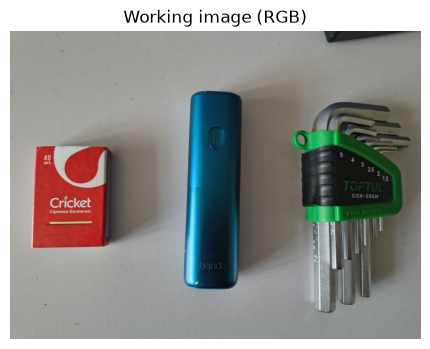

shape: (3072, 4096, 3) dtype: uint8
min/max: 0 255


In [ ]:
from pathlib import Path
from urllib.request import Request, urlopen

import cv2


def imread_url(url: str, timeout: int = 60):
    """Завантажує зображення з URL у масив BGR (OpenCV)."""
    req = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (compatible; OpenCV study #1)"},
    )
    with urlopen(req, timeout=timeout) as resp:
        data = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


IMAGE_URL = "https://www.dropbox.com/scl/fi/fptu6ben9xglurjpriqfz/sample.jpg?rlkey=2ng65qym8hge1qof5vwxresp5&st=ovx9ol6v&raw=1"
# IMAGE_URL = "https://www.bing.com/th?id=OHR.BoatsMalta_ROW6191359643_1920x1200.jpg&rf=LaDigue_1920x1200.jpg"

USE_URL = True  # False — лише локальний файл нижче

loaded = False
if USE_URL and IMAGE_URL:
    try:
        img_from_net = imread_url(IMAGE_URL)
        if img_from_net is None:
            raise ValueError("imdecode повернув None (можливо, не JPEG/PNG)")
        img_bgr = img_from_net
        loaded = True
        print("Завантажено зображення за посиланням.")
    except Exception as e:
        print(f"Помилка завантаження з URL: {e}")

if not loaded:
    path = Path("sample.jpg")  # змініть на ваш файл
    if path.exists():
        img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        print(f"Завантажено з файлу: {path.name}")
    else:
        print(f"Файл {path} не знайдено — використаємо синтетичне зображення.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
show(img_rgb, "Working image (RGB)")
print("shape:", img_bgr.shape, "dtype:", img_bgr.dtype)
print("min/max:", img_bgr.min(), img_bgr.max())


### 1.1.1. Відобразимо три кольорових канала окремо.

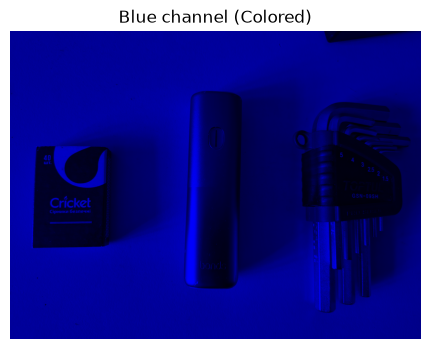

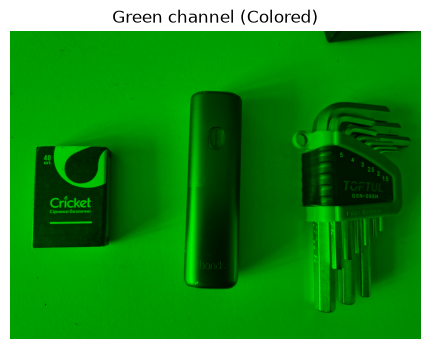

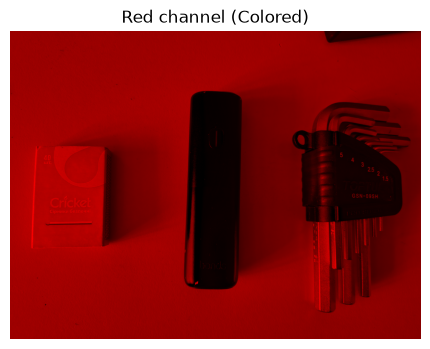

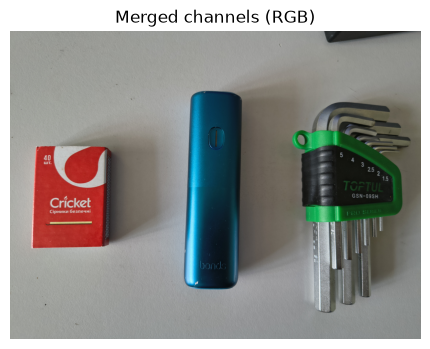

In [15]:
b, g, r = cv2.split(img_bgr)
zeros = np.zeros_like(b)

# Створюємо 3-канальні зображення, де працює лише один канал
img_blue  = cv2.merge([b, zeros, zeros])
img_green = cv2.merge([zeros, g, zeros])
img_red   = cv2.merge([zeros, zeros, r])

# Відображаємо (конвертуємо в RGB для коректного виводу через plt/show)
show(cv2.cvtColor(img_blue,  cv2.COLOR_BGR2RGB), 'Blue channel (Colored)')
show(cv2.cvtColor(img_green, cv2.COLOR_BGR2RGB), 'Green channel (Colored)')
show(cv2.cvtColor(img_red,   cv2.COLOR_BGR2RGB), 'Red channel (Colored)')

merged = cv2.merge([b, g, r])
show(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB), 'Merged channels (RGB)')

### 1.1.2. будуємо гістограму по каналах і гістограму каналу V у HSV – порівнюємо що інформативніше

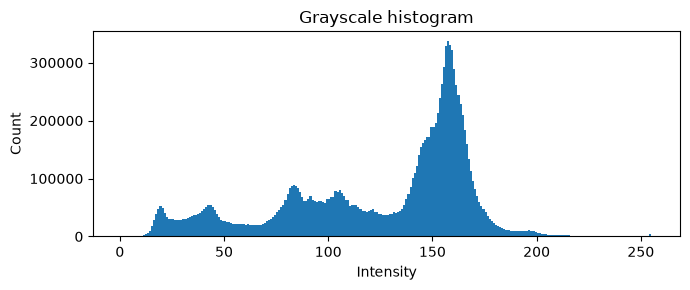

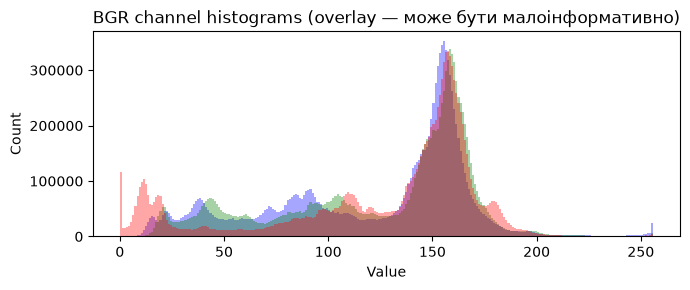

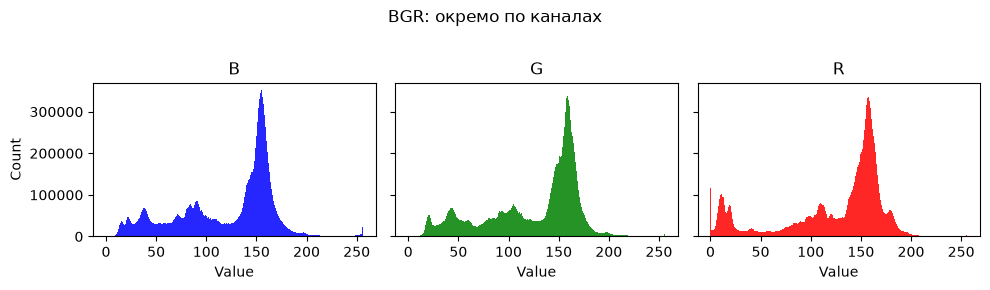

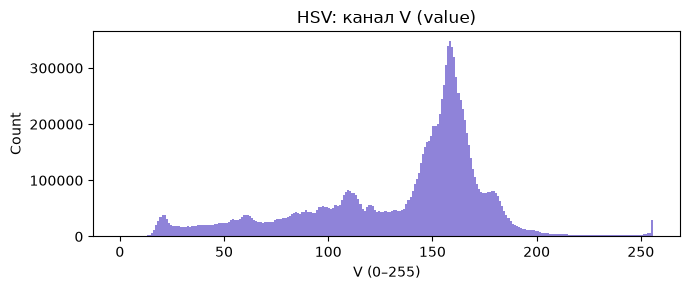

In [16]:
# Гістограма grayscale (потрібен img_bgr з клітинки завантаження)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(7, 3))
plt.title("Grayscale histogram")
plt.hist(gray.ravel(), bins=256, range=(0, 256))
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# BGR на одному графіку (часто «зливається» — див. пояснення вище)
colors = ["b", "g", "r"]
plt.figure(figsize=(7, 3))
plt.title("BGR channel histograms (overlay — може бути малоінформативно)")
for ch, c in zip(cv2.split(img_bgr), colors):
    plt.hist(ch.ravel(), bins=256, range=(0, 256), color=c, alpha=0.35)
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Той самий BGR — окремі осі (читабельніше)
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey=True)
for ax, ch, c, name in zip(axes, cv2.split(img_bgr), colors, ("B", "G", "R")):
    ax.hist(ch.ravel(), bins=256, range=(0, 256), color=c, alpha=0.85)
    ax.set_title(f"{name}")
    ax.set_xlabel("Value")
axes[0].set_ylabel("Count")
plt.suptitle("BGR: окремо по каналах", y=1.02)
plt.tight_layout()
plt.show()

# HSV — канал V (яскравість без відтінку): інколи наочніше для «світле/темне»
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
v = hsv[:, :, 2]
plt.figure(figsize=(7, 3))
plt.hist(v.ravel(), bins=256, range=(0, 256), color="slateblue", alpha=0.75)
plt.title("HSV: канал V (value)")
plt.xlabel("V (0–255)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 1.1.3.1. робимо center crop і resize до 224×224

H, W: 3072 4096 aspect ratio W/H: 1.3333333333333333


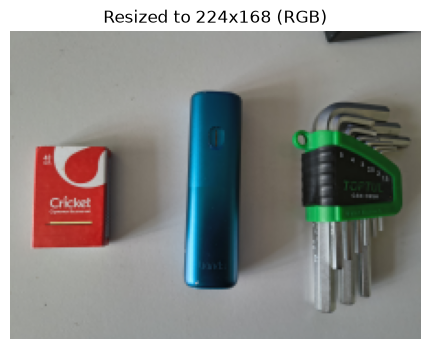

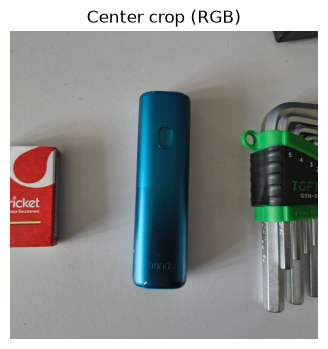

In [17]:
H, W = img_bgr.shape[:2]
print("H, W:", H, W, "aspect ratio W/H:", W / H)

# Resize (змінимо ширину до 224, збережемо пропорції)
new_w = 224
new_h = round(H * new_w / W)
resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
show(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB), f"Resized to {new_w}x{new_h} (RGB)")

# Crop (центральний квадрат)
side = min(H, W)
y0 = (H - side) // 2
x0 = (W - side) // 2
cropped = img_bgr[y0 : y0 + side, x0 : x0 + side]
show(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB), "Center crop (RGB)")


### 1.1.3.2. рахуємо розмір зображення для uint8 і float32 у MB.

In [18]:
def memory_megabytes(img: np.ndarray) -> float:
    return img.nbytes / (1024**2)

print(
    "Original  :",
    img_bgr.shape,
    "bytes:",
    img_bgr.nbytes,
    f"({memory_megabytes(img_bgr):.3f} MB)",
)
print(
    "Resized   :",
    resized.shape,
    "bytes:",
    resized.nbytes,
    f"({memory_megabytes(resized):.3f} MB)",
)
print(
    "Cropped   :",
    cropped.shape,
    "bytes:",
    cropped.nbytes,
    f"({memory_megabytes(cropped):.3f} MB)",
)

# Для embedded/реального pipeline часто важливий ще формат даних:
# uint8 (1 байт/канал) vs float32 (4 байти/канал)
img_f32 = img_bgr.astype(np.float32) / 255.0
print(
    "Float32   :",
    img_f32.shape,
    "bytes:",
    img_f32.nbytes,
    f"({memory_megabytes(img_f32):.3f} MB)",
)


Original  : (3072, 4096, 3) bytes: 37748736 (36.000 MB)
Resized   : (168, 224, 3) bytes: 112896 (0.108 MB)
Cropped   : (3072, 3072, 3) bytes: 28311552 (27.000 MB)
Float32   : (3072, 4096, 3) bytes: 150994944 (144.000 MB)


#### Підсумуємо: що розповіла гістограма про фото?

Гістограмми каналів B, G, R сильно корелюють між собою - іх форми майже повторюють один одного та накладаються. Це свідчить що колір на фото не сильно відрізняється від канала к каналу, натомість домінує яскравість (brightness).

Червоний (R) канал має додатковий пік біля 0, який відстуній на гістограмах іншіх каналів. З цього можемо зробити висновок, що на фото багато пікселів з відстуністю червоного.

Синій (B): помітна кількість пікселів з максимально насиченим синім у світлих/яскравих ділянках.

Зелений (G): подібних екстремальних сплесків майже непомітно.

HSV-гістограма повторює grayscale гістограму. Тож практичного зиску від використання HSV в порівнянні з grayscale гістограмою у випадку цього фото немає.

## 1.2. ДОДАТКОВЕ ЗАВДАННЯ

#### 1.2.1 Вимкнемо один канал `(img[:, :, 2] = 0)` і порівняємо результат з оригіналом

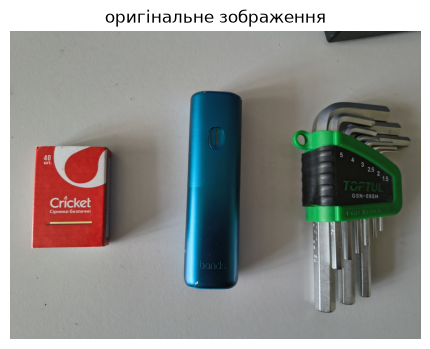

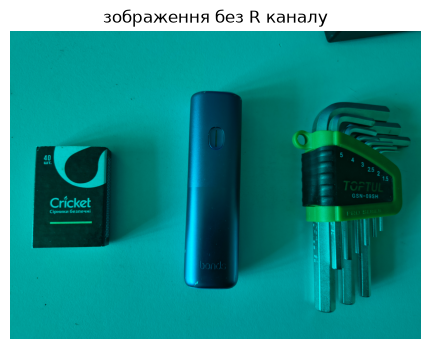

In [19]:
img_no_channel=img_bgr.copy() # робимо копію, щоб мутації не вплинули на оригінал
img_no_channel[:,:,2] = 0     # вимикаємо один канал - це R (червоний)
show(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), "оригінальне зображення")
show(cv2.cvtColor(img_no_channel, cv2.COLOR_BGR2RGB), 'зображення без R каналу')

можемо бачити, що в результаті вилучення червоного із фото, кінцевий результат отримав синьо-зелений віттінок.

#### 1.2.2. спробуємо alpha=0.5 (знижуємо контраст) і alpha=2.0 (підвищуємо) в `convertScaleAbs` – що відбувається з деталями
Пробуємо застосувати `alpha=0.5`

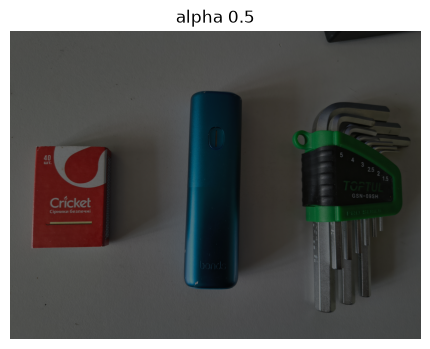

In [20]:
img_alpha05 = cv2.convertScaleAbs(img_bgr, alpha=0.5)
show(cv2.cvtColor(img_alpha05, cv2.COLOR_BGR2RGB), "alpha 0.5")

Пробуємо `alpha=2.0`

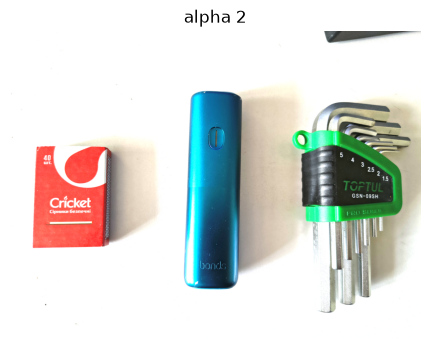

In [21]:
img_alpha2 = cv2.convertScaleAbs(img_bgr, alpha=2)
show(cv2.cvtColor(img_alpha2, cv2.COLOR_BGR2RGB), "alpha 2")


Можемо зробити висновок, що `alpha=2.0` додала __більше контрасту__ деталям на фото, тоді як `alpha=0.5` суттєво __зменьшила яскравість__ зображення.

#### 1.2.3. додамо шум sigma=10, 25 і 50 – при якому значенні деталі ще розпізнаються

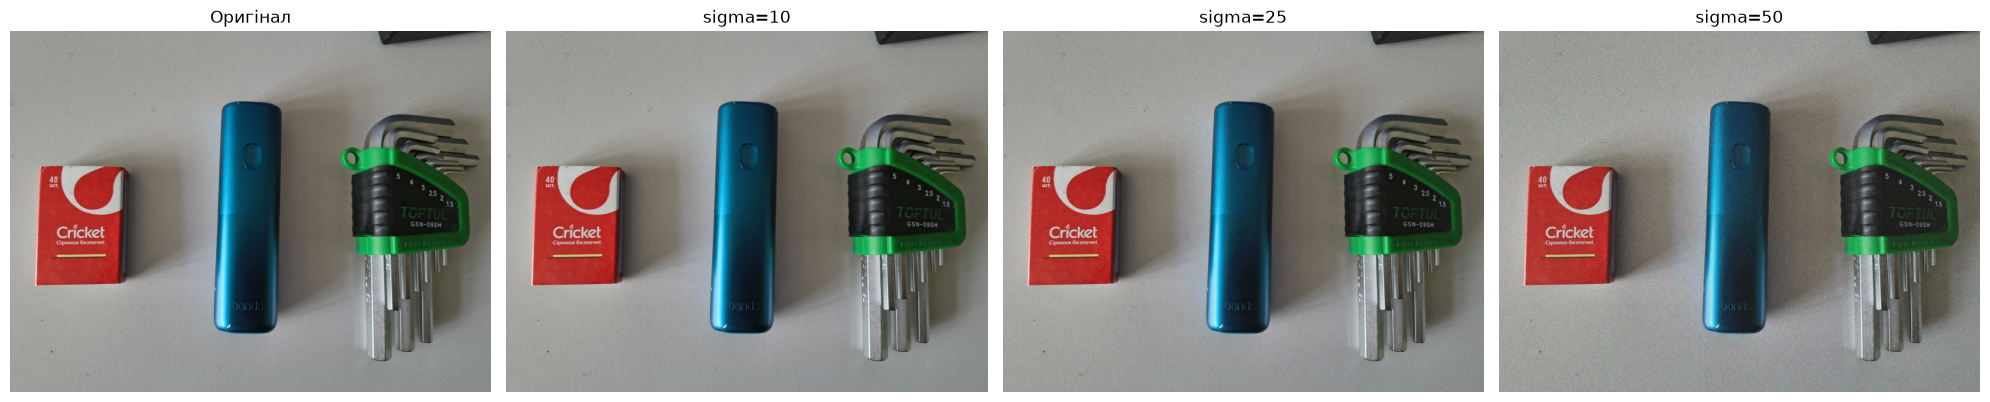

In [22]:
def add_gaussian_noise(img, sigma, mean=0):
    """Додає гаусів шум із заданою sigma до зображення (uint8, BGR/RGB)."""
    # генеруємо шум того ж розміру, що й зображення
    noise = np.random.normal(mean, sigma, img.shape).astype(np.int16)
    noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return noisy

# застосовуємо шум із різними sigma
img_sigma10 = add_gaussian_noise(img_rgb, sigma=10)
img_sigma25 = add_gaussian_noise(img_rgb, sigma=25)
img_sigma50 = add_gaussian_noise(img_rgb, sigma=50)

# візуалізація для порівняння
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Оригінал", "sigma=10", "sigma=25", "sigma=50"]
images = [img_rgb, img_sigma10, img_sigma25, img_sigma50]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


можемо констатувати, що для обраного фото для всіх варіантів, деталі зображення _чітко розпізнаються_.

#### 1.2.4. порахуймо пам'ять для 4K кадру (3840×2160×3) у `uint8` і `float32`.

In [23]:
h, w, c = 3840, 2160, 3
mb_uint8 = (h * w * c) / (1024**2)
mb_float32 = (h * w * c * 4) / (1024**2)
print(f"MB uint8  BGR 4K: {mb_uint8:.2f}")
print(f"MB float32 BGR 4K: {mb_float32:.2f}")

MB uint8  BGR 4K: 23.73
MB float32 BGR 4K: 94.92


In [24]:
assert abs(mb_float32 / mb_uint8 - 4.0) < 1e-6, "float32 має бути рівно в 4x більший!"
print("Перевірка OK: float32 = 4x uint8")

Перевірка OK: float32 = 4x uint8
